# Sobol' Indices: How Much Does Each Input Matter?

NB4 added a second uncertain input, ply thickness $t$, on top of the fiber strength $X_T$
already carried by NB2&ndash;3, and worked out the peak force $F_{peak}=w\,t\,X_T$'s exact
coefficient of variation from the two inputs' own CoVs. This notebook adds a **third**
uncertain input, the fiber-tension fracture energy $G_{fT}$, and a **second** output: the
full-failure displacement $\delta_f=2\,G_{fT}/X_T$ (NB1's own formula, Part "theoretical
background", step 5).

With $F_{peak}=w\,t\,X_T$ written down explicitly, you can already say something about which
input matters more: $t$ and $X_T$ sit symmetrically in that product, so nothing about the
formula's *shape* favours one over the other, and the split between them has to come from how
much each one actually scatters; a fact about the *inputs*, not the map. **That reasoning only
works because the map is written down.** A real Abaqus progressive-damage model has no such
formula to inspect: its relationship between an input and an output exists only as whatever the
solver computes, run by run. What is needed is a method that tells us how much of an output's
variance a given input is responsible for from nothing but *evaluations of the model*. That is
what a **Sobol' index** ([Sobol', 2001](https://doi.org/10.1016/S0378-4754(00)00270-6)) is: a
variance-based measure of how much of an output's scatter a given input, or group of inputs, is
responsible for, computable whether or not a closed form exists. This notebook derives what that
number means from first principles, works it out exactly for both of this model's outputs (one
of them up to a single one-dimensional numerical integral, Part 3), builds the general-purpose
Monte Carlo estimator that needs no closed form at all, and checks the two against each other.
Like NB4, this notebook stays entirely analytical and runs no Abaqus job.

**Learning objectives**

- Understand what a Sobol' index measures, and why the *first-order* index $S_i$ and the
  *total* index $S_i^{\mathrm{tot}}$ answer two different questions about the same input.
- Derive the Sobol' decomposition of a model's output into per-input and per-interaction pieces
  from first principles, and see why it makes the output's variance split into additive shares.
- Derive the *exact* Sobol' indices for both $F_{peak}$ and $\delta_f$.
- Implement the general-purpose **pick-freeze** Monte Carlo estimator, check it against SciPy's
  own implementation, and use the same set of draws to estimate indices for *both* outputs at
  once.
- Run three campaigns at different levels of input scatter and read how the Sobol' indices move
  with the scatter, not just with the formula.

**Notation.** $d=3$ independent inputs: ply thickness $t$, fiber tensile strength $X_T$, and
fiber-tension fracture energy $G_{fT}$; $\mathrm{CoV}_t$, $\mathrm{CoV}_{X_T}$,
$\mathrm{CoV}_{G_{fT}}$ (shortened to $\mathrm{CoV}_G$) their coefficients of variation, and
$\mu_t,\mu_{X_T},\mu_{G_{fT}}$ ($\mu_{G_{fT}}$ shortened to $\mu_G$), $\sigma_t,\sigma_{X_T},
\sigma_{G_{fT}}$ their means and standard deviations. Two outputs: $F_{peak}$ and $\delta_f$.
$\mathrm{Var}(\cdot)$ is an output's variance; $D$ is the same quantity written the way Part 2
below builds it up, as a sum of pieces $D_S$, one per input or group of inputs $S$. $S_i$ is
input $i$'s **first-order** Sobol' index for a given output; $S_i^{\mathrm{tot}}$ its **total**
index. $n$ denotes a Monte Carlo campaign's *running* sample size while it grows; $N$ denotes a
campaign's *converged* size, and the sample size in every estimator formula below. Units
throughout, as in the rest of the series: **mm / N / MPa** ($1$ MPa $=1$ N/mm$^2$), fracture
energies in N/mm.


## Part 1 &ndash; Three inputs, two outputs

Two closed-form outputs, both introduced earlier in this series:

$$F_{peak} = w\,t\,X_T, \qquad \delta_f = \frac{2\,G_{fT}}{X_T}.$$

$F_{peak}$ is a **capacity**: the design question is how *weak* a realisation could plausibly
be, so it is tracked at its **5th** percentile, the low tail NB2&ndash;4 have used throughout.
$\delta_f$ is a **deformation**, how far the structure must be pushed before the fiber-tension
mode finishes failing, so the demanding realisations are the *large* ones, and it is tracked at
its **95th** percentile instead. We are going to use the same order-statistic-plus-bootstrap machinery either way (Part
4 below); only the tail changes, because the physical question does.

Three inputs, independent and Normal:

$$t \sim \mathcal N(t_0,\ \mathrm{CoV}_t\cdot t_0), \qquad
X_T \sim \mathcal N(990,\ 49.5)\ \text{MPa}, \qquad
G_{fT} \sim \mathcal N(G_0,\ \mathrm{CoV}_G\cdot G_0)\ \text{N/mm}$$

with $t_0=0.20$ mm and $X_T$'s marginal unchanged since NB2 ($\mathrm{CoV}_{X_T}=5\%$).
$G_{fT}$'s **mean**, $G_0=1290$ N/mm, is NB1's own sourced value
([Nelson et al., 2017](https://doi.org/10.5194/wes-2-653-2017)); its CoV, like
$\mathrm{CoV}_t$, is left free, so that Parts 4&ndash;5 can sweep it. Independence between all three
inputs is assumed, exactly as NB4 assumed it between $t$ and $X_T$: the simplest honest
starting point, and a real requirement for everything derived below.

**Which input enters which map.** $F_{peak}$ does not have $G_{fT}$ as an argument; $\delta_f$
does not have $t$ as an argument. An input that a formula cannot see cannot move that formula's
variance, whatever its own scatter does. We will see this observation in the results below.

**The genuinely open question.** Among $t$ and $X_T$ (both arguments of $F_{peak}$), or among
$X_T$ and $G_{fT}$ (both arguments of $\delta_f$), which one dominates? One pair sits symmetrically in its map, and what
breaks the symmetry is how much each input actually scatters. The other pair does not sit symmetrically in its map, so the dominance is also influenced by the map itself. We consider three cases, by moving one CoV at a time:

$$\begin{array}{c|c|c}
 & \mathrm{CoV}_t & \mathrm{CoV}_{G_{fT}} \\\hline
\text{Case 1} & 2\% & 5\% \\
\text{Case 2} & 5\% & 5\% \\
\text{Case 3} & 5\% & 10\%
\end{array}$$

$\mathrm{CoV}_{X_T}=5\%$ throughout. As in NB4, these $\mathrm{CoV}_t$ and
$\mathrm{CoV}_{G_{fT}}$ values are **illustrative sweep points**, chosen to make a mechanism
visible, not sourced estimates of real ply-thickness or fracture-energy scatter. Case
1&rarr;2 raises only $\mathrm{CoV}_t$, to match $\mathrm{CoV}_{X_T}$ exactly; Case 2&rarr;3
raises only $\mathrm{CoV}_G$, to double $\mathrm{CoV}_{X_T}$. Part 3 works out what each step
should do to the indices, exactly, before any sampling; Part 5 runs the actual
campaigns.

The cells below set up the two maps and the three marginals, then draw a sample purely to look at.


In [1]:
import sys
from pathlib import Path

import numpy as np

# This notebook's own helper modules live in ../scripts. Neither touches Abaqus, so both are
# safe to import straight into a live kernel (unlike build_fiber_tension.py -- see NB1).
sys.path.insert(0, "../scripts")

# ---------------------------------------------------------------------------------------
# The three input marginals and the two fixed geometric/loading constants.
# ---------------------------------------------------------------------------------------
MU_XT, SIGMA_XT = 990.0, 49.5    # MPa  -- X_T ~ N(990, 49.5), unchanged since NB2 (CoV_XT = 5%)
COV_XT = SIGMA_XT / MU_XT
T0 = 0.20                        # mm   -- nominal ply thickness (NB1 geometry)
MU_G = 1290.0                    # N/mm -- nominal G_fT (Nelson et al., 2017; NB1's own sourced value)
W = 10.0                         # mm   -- gauge width (NB1 geometry), fixed throughout
D_INPUTS = 3                     # d -- t, X_T, G_fT


Two outputs need one function each. Both maps take the same $(t,X_T,G_{fT})$ triple, so a
single helper function that returns both saves drawing the sample twice. The two maps are also where
each input's own seed comes in: drawing $t$, $X_T$ and $G_{fT}$ from three separate random
generators is what makes them independent by construction, exactly as NB4 built independence
between $t$ and $X_T$ from two separate seeds. `SEED_A` is the only stream that draws the
random vector $(t, X_T, G_{fT})$ in Parts 1&ndash;4; a second stream, `SEED_B`, is introduced
only in Part 5, where the pick-freeze estimator needs a second, independent sample.

In [2]:
# One named seed per INPUT (not one seed for the whole vector): each column of the sample is
# drawn from its own generator, so no two inputs share any randomness. X_T's and t's seeds (2
# and 4) are NB2/NB3/NB4's own; G_fT's seed (6) is new here.
SEED_A = dict(t=4, x=2, g=6)


def draw_pool(cov_t, cov_g, n, seeds=SEED_A):
    """Draw n independent (t, X_T, G_fT) triples at the given CoVs, one column per input, each
    from its own named seed. Returns an (n, 3) array, columns [t, X_T, G_fT]."""
    z_t = np.random.default_rng(seeds["t"]).standard_normal(n)
    x_t = np.random.default_rng(seeds["x"]).normal(MU_XT, SIGMA_XT, n)
    z_g = np.random.default_rng(seeds["g"]).standard_normal(n)
    t = T0 * (1.0 + cov_t * z_t)
    g = MU_G * (1.0 + cov_g * z_g)
    return np.column_stack([t, x_t, g])


def outputs(M):
    """M: (n, 3) array [t, X_T, G_fT]. Returns a (2, n) array, row 0 = F_peak, row 1 = delta_f --
    the small-strain maps from Part 1, evaluated on every row of M at once."""
    t, x, g = M[:, 0], M[:, 1], M[:, 2]
    return np.vstack([W * t * x, 2.0 * g / x])


With the marginals, the seeds and the two maps in hand, the cell below draws a large sample at
Case 3's CoVs (the widest scatter used anywhere in this notebook, so the spread is actually
visible), plots all three input marginals and both output marginals, and prints the realised
mean/CoV per input and the $3\times3$ input correlation matrix, so that we can see what the data looks like.

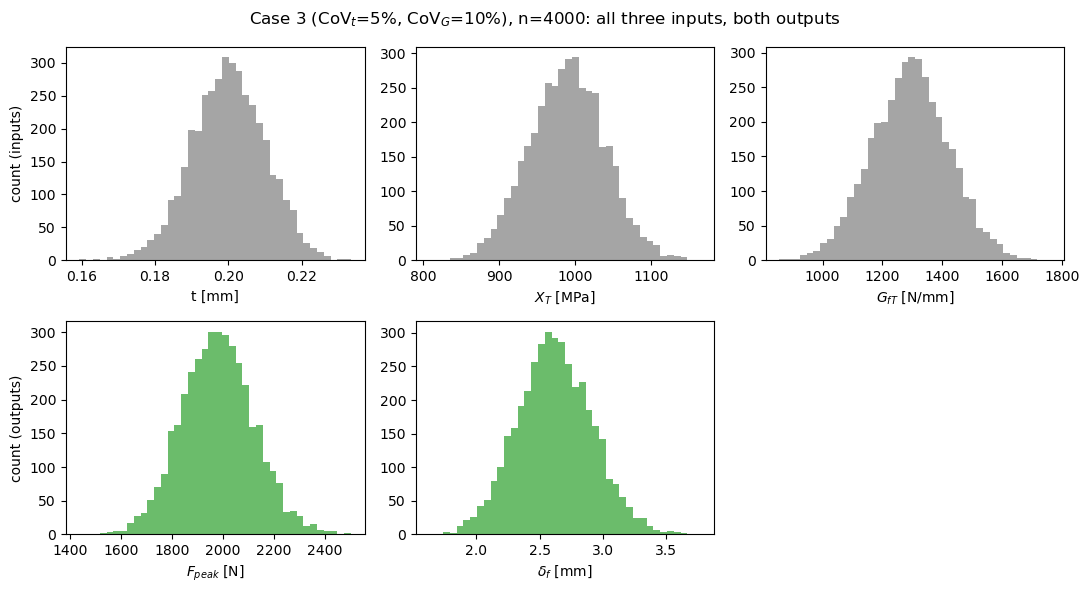

 input        mean       CoV
     t      0.2000    0.0498
   X_T    989.3385    0.0502
  G_fT   1293.2469    0.1001

input correlation matrix (independent draws -> expect all off-diagonals close to 0):
               t      X_T     G_fT
     t    1.0000   0.0213   0.0136
   X_T    0.0213   1.0000  -0.0191
  G_fT    0.0136  -0.0191   1.0000


In [3]:
import matplotlib.pyplot as plt

# The three (CoV_t, CoV_G) cases from Part 1's table above, and one colour per case, reused in
# every figure below so a case is always recognisable by colour alone.
CASES = {1: (0.02, 0.05), 2: (0.05, 0.05), 3: (0.05, 0.10)}   # case -> (CoV_t, CoV_G)
CASE_COLOR = {1: "C0", 2: "C1", 3: "C2"}

# Draw purely to look at, at Case 3's CoVs (the widest scatter, so the spread is visible).
N_LOOK = 4000
cov_t_look, cov_g_look = CASES[3]
M_look = draw_pool(cov_t_look, cov_g_look, N_LOOK)
F_look, D_look = outputs(M_look)

# A 2x3 grid: top row = the three input marginals, bottom-left/-middle = the two output
# marginals, bottom-right left empty (three inputs, only two outputs).
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
input_panels = [("t [mm]", M_look[:, 0]), ("$X_T$ [MPa]", M_look[:, 1]), ("$G_{fT}$ [N/mm]", M_look[:, 2])]
for ax, (label, sample) in zip(axes[0], input_panels):
    ax.hist(sample, bins=40, color="C7", alpha=0.7)
    ax.set_xlabel(label)
axes[0, 0].set_ylabel("count (inputs)")

output_panels = [("$F_{peak}$ [N]", F_look), ("$\\delta_f$ [mm]", D_look)]
for ax, (label, sample) in zip(axes[1, :2], output_panels):
    ax.hist(sample, bins=40, color="C2", alpha=0.7)
    ax.set_xlabel(label)
axes[1, 0].set_ylabel("count (outputs)")
axes[1, 2].axis("off")   # unused corner -- three inputs, only two outputs

fig.suptitle(rf"Case 3 ($\mathrm{{CoV}}_t$={cov_t_look:.0%}, $\mathrm{{CoV}}_G$={cov_g_look:.0%}), "
             f"n={N_LOOK}: all three inputs, both outputs")
fig.tight_layout()
plt.show()

# The numbers behind the picture: realised mean/CoV per input, and the 3x3 correlation matrix --
# the direct test that the three input streams really are independent.
labels = ["t", "X_T", "G_fT"]
means = M_look.mean(axis=0)
covs = M_look.std(axis=0, ddof=1) / means
corr = np.corrcoef(M_look, rowvar=False)

print(f"{'input':>6}{'mean':>12}{'CoV':>10}")
for lab, mu, cv in zip(labels, means, covs):
    print(f"{lab:>6}{mu:12.4f}{cv:10.4f}")

print(f"\ninput correlation matrix (independent draws -> expect all off-diagonals close to 0):")
print("       " + "".join(f"{lab:>9}" for lab in labels))
for lab, row in zip(labels, corr):
    print(f"{lab:>6} " + "".join(f"{v:9.4f}" for v in row))

All three marginals land on their target mean and CoV to within ordinary sampling
error, and every off-diagonal entry of the correlation matrix sits close to zero. Both output
histograms are visibly scattered, but nothing in a histogram says *which* input is responsible
for how much of either spread. Part 2 defines the number built to answer exactly that.

## Part 2 &ndash; What a Sobol' index measures

### Three definitions to have in hand first

Everything below is built from three ordinary statistical concepts, recalled here for convenience.

- **Expectation, $\mathrm E[\cdot]$.** An average over an input's randomness. This is not one
  number computed from one draw, but the number you would converge to by drawing forever and
  averaging. $\mathrm E[X_T]=\mu_{X_T}=990$ MPa is a concrete instance you already know.
- **Variance**, $$\mathrm{Var}(Y) = \mathrm E\big[(Y-\mathrm E[Y])^2\big] = \mathrm E[Y^2]-\mathrm E[Y]^2,$$
  in words, the average squared distance from the mean. Both forms are used below: the first
  because it is what "spread" means, the second because it is the one a computer actually sums.
- **Finite variance.** $f$ has finite variance if $\mathrm E[f^2]<\infty$, meaning that the output
  does not scatter so wildly that its own variance is infinite. Both of this notebook's maps
  satisfy this trivially (finite inputs raised to finite powers).

### The Sobol' decomposition

Take any output $f(x_1,\dots,x_d)$ of $d$ independent inputs with finite variance, and nothing
else assumed. [Sobol' (2001)](https://doi.org/10.1016/S0378-4754(00)00270-6) shows any such $f$
can always be written as a sum

$$f(x) = f_0 + \sum_i f_i(x_i) + \sum_{i<j} f_{ij}(x_i,x_j) + \dots + f_{12\cdots d}(x_1,\dots,x_d).$$

Each piece of the expression above composes the decomposition of $f$: $f_0$ is a constant (the output's overall mean); $f_i$ is a function of $x_i$ alone,
one per input; $f_{ij}$ is a function of the pair $(x_i,x_j)$, one per pair of inputs; and so
on up to the one term that depends on every input at once. Read in words: $f_i(x_i)$ is the
part of the output that $x_i$ moves *on its own*, with every other input's randomness averaged
away; $f_{ij}(x_i,x_j)$ is the *extra* part that the pair $(x_i,x_j)$ moves together, beyond
what $f_i$ and $f_j$ already account for individually. Nothing here is specific to this
notebook's two maps: the decomposition exists for any $f$ satisfying the two conditions
above, whatever its shape.

**Conditional expectation, needed to pin the decomposition down.** The sum above is
not unique. For instace, you could always move a constant from $f_i$ into $f_0$. Fixing it needs
one new idea: $\mathrm E[f\mid x_i]$, read "the expectation of $f$ given $x_i$." It means:
freeze $x_i$ at one particular value, then average $f$ over every *other* input's randomness,
leaving $x_i$ untouched. The result is a function of $x_i$ alone, a different number for
every value $x_i$ could take. Concretely, on this notebook's own map: freezing $t$ and
averaging $F_{peak}=w\,t\,X_T$ over $X_T$'s randomness gives $\mathrm E[F_{peak}\mid
t]=w\,t\,\mathrm E[X_T]=w\,t\,\mu_{X_T}$, which is a function of $t$ only.

**What pins the decomposition down uniquely.** The extra condition is that every term other
than $f_0$ has **zero mean** over each of its own arguments, $\mathrm
E_{x_k}[f_{i_1\cdots i_s}]=0$ for every $k$ among $i_1,\dots,i_s$. That condition has a direct,
constructive reading, using conditional expectation to build the decomposition from the bottom
up: each term is "what conditioning on this many inputs explains, minus what the simpler terms
below it already explained,"

$$f_0=\mathrm E[f], \qquad f_i(x_i)=\mathrm E[f\mid x_i]-f_0, \qquad
f_{ij}(x_i,x_j)=\mathrm E[f\mid x_i,x_j]-f_i-f_j-f_0,$$

and so on. Each term is, by construction, whatever is left over once every smaller group's
contribution has been removed, which is exactly why $f_i$ cannot smuggle in an effect
that really belongs to $f_{ij}$, or vice versa.

### Why this makes variances add

The question this notebook actually needs answered is *how much of the output's variance* each
term is responsible for. Getting there takes three short steps, using the decomposition and the
zero-mean condition from above.

**1. Orthogonality: different terms don't correlate.** Recall first the ordinary rule for
independent randomness: if $g$ is a function of $x_k$ alone and $h$ is a function that does not
involve $x_k$ at all, then $\mathrm E[g(x_k)\,h] = \mathrm E[g(x_k)]\cdot\mathrm E[h]$; in other words,
averaging a product of two *independent* pieces is the same as multiplying their two separate
averages. 

Take two *different* decomposition terms $f_S=f_{i_1\cdots i_s}$ and $f_T=f_{j_1\cdots j_t}$ from the sum, where "different" means $S\ne T$ as index
*sets*, e.g. $f_S=f_{12}$ and $f_T=f_{13}$. Since $S\ne T$, some input $x_k$ appears in one set but not the
other. For instance, say $k\in S\setminus T$, so $f_T$ does not depend on $x_k$ at all. Split the average over *all* the inputs into two stages: first average
over $x_k$ alone, holding every other input fixed; then average what is left over everything
else. In that inner average, $x_k$ is the only thing varying and $f_T$ contains no $x_k$, so
$f_T$ is just a constant there and can be pulled outside it:
$$\mathrm E[f_S f_T] = \mathrm E_{x_{\setminus k}}\Big[f_T\cdot \mathrm E_{x_k}[f_S]\Big] = 0,$$
because $\mathrm E_{x_k}[f_S]=0$ is exactly the zero-mean condition above (it holds no matter
what the other inputs, held fixed in the outer average, happen to be). Any two *different*
decomposition terms are therefore uncorrelated: $\mathrm E[f_Sf_T]=0$ whenever $S\ne T$,
however large or small $S$ and $T$ individually are.

**2. Squaring the sum.** Write $f-f_0=\sum_{S\ne\emptyset}f_S$ (every term except the constant).
Squaring a sum of two pieces gives $(a+b)^2=a^2+b^2+2ab$; squaring a sum of three gives
$a^2+b^2+c^2+2ab+2ac+2bc$. In other words, if we square $f-f_0$, we get on the right-hand side the sum of
every term's own square ($S=T$), plus every *mixed product* of two
different terms ($S\ne T$, e.g. $2ab$), each counted twice (once each way, which is why the
general sum below writes it as an ordered sum over $S\ne T$ rather than doubling an unordered
one). The same pattern holds for a sum of any number of terms $f_S$:
$$(f-f_0)^2 = \Big(\sum_S f_S\Big)^2 = \sum_S f_S^2 + \sum_{S\ne T} f_S f_T.$$

Remember that the sum over $S$ runs over *every* non-empty subset of the $d$ inputs, including singletons $f_i$ and interaction terms $f_{ij}$, $f_{ijk}$, etc. The sum over $S\ne T$ runs over every *pair* of distinct subsets, including pairs of singletons, pairs of interactions, and mixed pairs. Taking the expectation of both sides of the expression above, every one of those pairs of distinct subsets vanishes by Step 1 (each is exactly one $\mathrm E[f_Sf_T]$,
$S\ne T$), leaving only the squared terms $\sum_S f_S^2$ on the right-hand side.

**3. Assemble.** $D\equiv\mathrm{Var}(f)=\mathrm E[(f-f_0)^2]$ (the variance identity recalled
above, applied to $f$), so Step 2 gives
$$D = \sum_S D_S, \qquad D_S \equiv \mathrm E[f_S^2] = \mathrm{Var}(f_S).$$

Remember that $S$ is not an input index, but an index *set*, and the sum runs over *every* non-empty subset of the $d$ inputs, singletons and
groups alike. For this notebook's $d=3$ inputs $\{t,X_T,G_{fT}\}$, relabelled $\{1,2,3\}$ for
brevity, that is all seven non-empty subsets of $\{1,2,3\}$, and the sum above is, in full,
$$D = \underbrace{D_1+D_2+D_3}_{\text{one input alone, }3\text{ terms}}
\;+\; \underbrace{D_{12}+D_{13}+D_{23}}_{\text{two inputs together, }3\text{ terms}}
\;+\; \underbrace{D_{123}}_{\text{all three, }1\text{ term}}.$$

Every interaction partial variance ($D_{12}$, $D_{13}$, $D_{23}$, $D_{123}$) is a term in this
sum, on exactly the same footing as $D_1$, $D_2$, $D_3$. The mixed products between different terms vanish as described in Step 2. This is why the next
subsection can define a Sobol' index $S_{12}=D_{12}/D$ for an interaction exactly as it defines
$S_1=D_1/D$ for a single input: both $D_{12}$ and $D_1$ are addends of the very same total $D$,
so both have a well-defined share of it.

Each piece $D_S$, called a **partial variance**, is literally the variance of one Sobol' term
(single-input or interaction alike), and the pieces add up to the output's total variance with
nothing left over and nothing double-counted. This holds for *any* square-integrable $f$ of
independent inputs, whatever its shape.


### First-order and total indices

[Sobol' (2001)](https://doi.org/10.1016/S0378-4754(00)00270-6) divides every partial variance
by the total:
$$S_{i_1\cdots i_s} = D_{i_1\cdots i_s}/D.$$
We call this object a **Sobol' index**. Because the pieces sum to $D$ exactly, the indices sum to exactly 1: a
Sobol' index is a **share of a variance budget**. The **first-order** (or **main-effect**)
Sobol' index of input $i$, $S_i=D_i/D$, is literally "the fraction of the output's variance
explained by $X_i$ acting alone."

$S_i$ only credits $X_i$ acting *alone*. If $X_i$ mostly matters together with another input,
through an interaction term like $D_{ij}$, $S_i$ never sees that share, as it belongs to
the pair, not to $X_i$. The **total** Sobol' index $S_i^{\mathrm{tot}}$ closes that gap by
collecting $S_i$ with every higher-order term $X_i$ takes part in. For instance, for three
inputs, $X_1$'s total index is $S_1^{\mathrm{tot}} = S_1+S_{12}+S_{13}+S_{123}$. Two
consequences follow directly:

- $S_i\le S_i^{\mathrm{tot}}$ always, with equality exactly when $X_i$ takes part in no
  interaction at all.
- $\sum_i S_i\le 1\le \sum_i S_i^{\mathrm{tot}}$: first-order indices under-count (an
  interaction is shared, not owned by one input); total indices over-count, in the opposite
  direction.

**$S_i^{\mathrm{tot}}=0$ is the strong statement this notebook leans on.** Because
$S_i^{\mathrm{tot}}$ already contains every term $X_i$ enters, $S_i^{\mathrm{tot}}=0$ means
$X_i$ contributes to *none* of them, including jointly with another input. This is a valuable information because an input with
a negligible total index can be fixed at its nominal value with no meaningful consequence, not even
through an interaction. Part 5 reports both indices for every input, output and case.


## Part 3 &ndash; Working the indices out exactly for this model

### $F_{peak}$ decomposition

In order to derive the Sobol' decomposition directly for $F_{peak}$, we want to sort the product $t\,X_T$ by fluctuation order. To do this, we write each input as its mean plus a mean-zero fluctuation: $t=\mu_t+(t-\mu_t)$ and $X_T=\mu_{X_T}+(X_T-\mu_{X_T})$. Expanding $t\,X_T$ this way gives one term with zero fluctuations, two with one fluctuation component, and one with two fluctuation components:

$$t\,X_T = \underbrace{\mu_t\mu_{X_T}}_{f_0} + \underbrace{\mu_{X_T}(t-\mu_t)}_{f_t(t)}
+ \underbrace{\mu_t(X_T-\mu_{X_T})}_{f_{X_T}(X_T)} + \underbrace{(t-\mu_t)(X_T-\mu_{X_T})}_{f_{tX_T}(t,X_T)},$$

Each of $f_t$, $f_{X_T}$, $f_{tX_T}$ is automatically mean-zero in each of its own arguments, as every one of them is proportional to a mean-zero fluctuation like
$(t-\mu_t)$, so integrating over that input alone gives zero for free. That is exactly Part 2's uniqueness condition, satisfied without having to check it: this expansion already *is* the Sobol' decomposition, not merely *a* possible one.

**$D_t$, step by step.** Squaring $f_t(t)=\mu_{X_T}(t-\mu_t)$ gives
$f_t(t)^2=\mu_{X_T}^2(t-\mu_t)^2$. $\mu_{X_T}$ is a fixed constant, as it carries no randomness of its own, so it comes straight out of the expectation:
$$D_t=\mathrm E[f_t^2]=\mu_{X_T}^2\,\mathrm E\big[(t-\mu_t)^2\big].$$
What remains, $\mathrm E[(t-\mu_t)^2]$, is *exactly* the definition of $\mathrm{Var}(t)$ recalled
in Part 2, the average squared distance of $t$ from its own mean, so it equals
$\sigma_t^2$ by that definition, giving:
$$D_t=\mu_{X_T}^2\sigma_t^2.$$

**$D_{tX_T}$, the same two steps.** Squaring the interaction term gives
$f_{tX_T}^2=(t-\mu_t)^2(X_T-\mu_{X_T})^2$, a product of a function of $t$ alone and a function
of $X_T$ alone. Because $t$ and $X_T$ are independent, the expectation of that product *is* the
product of the two separate expectations (the same independence rule Part 2's orthogonality
step used):
$$D_{tX_T}=\mathrm E\big[(t-\mu_t)^2\big]\,\mathrm E\big[(X_T-\mu_{X_T})^2\big]=\sigma_t^2\sigma_{X_T}^2.$$

**Turning each $D$ into a squared CoV.** Divide every one of $D_t$, $D_{X_T}$, $D_{tX_T}$ by
$(\mu_t\mu_{X_T})^2$; this is allowed because a Sobol' index is a *ratio* of two $D$'s,
and dividing every $D$ by the same constant leaves every ratio unchanged. For $D_t$ this gives
$$\frac{D_t}{(\mu_t\mu_{X_T})^2} = \frac{\mu_{X_T}^2\sigma_t^2}{\mu_t^2\mu_{X_T}^2} =
\frac{\sigma_t^2}{\mu_t^2} = \mathrm{CoV}_t^2,$$
and the same steps on the other two give

$$D_t=\mathrm{CoV}_t^2, \qquad D_{X_T}=\mathrm{CoV}_{X_T}^2, \qquad D_{tX_T}=\mathrm{CoV}_t^2\,\mathrm{CoV}_{X_T}^2,
\qquad D=D_t+D_{X_T}+D_{tX_T},$$

writing $D$ for the normalised total from here on. Note that this is NB4's own exact $\mathrm{CoV}_F^2$ identity, now split into three shares instead of
summed. Since only $t$ and $X_T$ appear, $S_t^{\mathrm{tot}}=S_t+D_{tX_T}/D$ and
$S_{X_T}^{\mathrm{tot}}=S_{X_T}+D_{tX_T}/D$ share the same interaction term, and $G_{fT}$'s index
is exactly zero, since $F_{peak}$ has no $G_{fT}$-dependent term at all.

Everything here used only independence and finite variance, meaning that the result holds for $t,X_T$ of any shape, not just Normal.

The cell below turns this derivation into two small functions and prints the resulting indices
for all three cases.


In [4]:
def exact_indices_product(cov_a, cov_b):
    """Exact first-order and total Sobol' indices for a product of two independent factors with
    coefficients of variation cov_a, cov_b (Part 3's derivation above; the same algebra covers
    both F_peak = w*t*X_T, with (cov_a, cov_b) = (CoV_t, CoV_XT), and delta_f = 2*G_fT*(1/X_T),
    with (cov_a, cov_b) = (CoV_R, CoV_G) below). Returns (S_a, S_b, S_int, ST_a, ST_b)."""
    D_a, D_b = cov_a ** 2, cov_b ** 2       # normalised partial variances of the two factors
    D_ab = cov_a ** 2 * cov_b ** 2          # normalised interaction partial variance
    D = D_a + D_b + D_ab                    # normalised total variance -- all three shares
    S_a, S_b, S_int = D_a / D, D_b / D, D_ab / D   # first-order indices + the shared interaction share
    return S_a, S_b, S_int, S_a + S_int, S_b + S_int   # total index = first-order + interaction


def exact_indices_fpeak(cov_t, cov_x=COV_XT):
    """Exact Sobol' indices for F_peak = w*t*X_T, for all three inputs. Returns (S, ST), each a
    length-3 array ordered [t, X_T, G_fT] -- G_fT's entry is exactly 0.0 (not an argument)."""
    S_t, S_x, _, ST_t, ST_x = exact_indices_product(cov_t, cov_x)
    return np.array([S_t, S_x, 0.0]), np.array([ST_t, ST_x, 0.0])


# One row per case: all three CoVs (CoV_XT never changes, printed anyway so every input's
# scatter is visible on the same line as the indices it produces), then F_peak's first-order
# and total Sobol' indices for [t, X_T, G_fT].
print(f"{'case':>6}{'CoV_t':>8}{'CoV_XT':>8}{'CoV_G':>8}   {'S_t':>8}{'S_XT':>8}{'S_G':>8}   "
      f"{'ST_t':>8}{'ST_XT':>8}{'ST_G':>8}")
for c, (cov_t, cov_g) in CASES.items():
    S, ST = exact_indices_fpeak(cov_t)
    print(f"{c:>6}{cov_t:8.2f}{COV_XT:8.2f}{cov_g:8.2f}   " + "".join(f"{v:8.4f}" for v in S) +
          "   " + "".join(f"{v:8.4f}" for v in ST))


  case   CoV_t  CoV_XT   CoV_G        S_t    S_XT     S_G       ST_t   ST_XT    ST_G
     1    0.02    0.05    0.05     0.1379  0.8618  0.0000     0.1382  0.8621  0.0000
     2    0.05    0.05    0.05     0.4994  0.4994  0.0000     0.5006  0.5006  0.0000
     3    0.05    0.05    0.10     0.4994  0.4994  0.0000     0.5006  0.5006  0.0000


In case 1 the split is roughly 14%/86% and $X_T$ dominates by a wide margin. Case 2 raises $\mathrm{CoV}_t$ to match $\mathrm{CoV}_{X_T}$, and
$S_t,S_{X_T}$ become equal (both variance pieces are the same expression with $t$ and $X_T$
swapped), landing near, not exactly at, 50% each. The remainder belongs to the
interaction $D_{tX_T}/D$ their equal scatter also produces. The gap between first-order and total indices corresponds to the interaction term itself: $S_t=0.4994$
against $S_t^{\mathrm{tot}}=0.5006$ (and symmetrically for $X_T$), with $D_{tX_T}/D=0.0012$. That is also why the first-order indices sum to $0.9988$, just under
1, while the totals sum to $1.0012$, just over. he interaction is small here
because $D_{tX_T}/D\propto\mathrm{CoV}_t^2\mathrm{CoV}_{X_T}^2$ is a product of two already-small
squared CoVs (of order $0.05^2\times0.05^2\approx6\times10^{-6}$ relative to $D_t,D_{X_T}$ of
order $0.05^2\approx2.5\times10^{-3}$) &ndash; at these scatter levels, first-order and total
indices are close, even though they are not identical. Case 3 changes only $\mathrm{CoV}_G$, which does not appear in $F_{peak}$'s formula at all, so its row repeats
Case 2's exactly.

### $\delta_f$ decomposition

While $\delta_f=2G_{fT}/X_T$ involves a ratio and not a product, it can be rewritten as a product by introducing the reciprocal of $X_T$:

$$\delta_f = (2\,G_{fT})\cdot\left(\frac{1}{X_T}\right) = (2\,G_{fT})\cdot R, \qquad R\equiv\frac1{X_T}.$$

$G_{fT}$ and $R$ are still independent (a function of $X_T$ alone can't correlate with
$G_{fT}$), so Part 3's product decomposition above transfers **unchanged**, with $X_T$ replaced by $R$.

**The one non-elementary ingredient: $\mathrm{CoV}_R$.** Everything above needs $R$'s own
coefficient of variation, $\mathrm{CoV}_R=\sigma_R/\mu_R$, and getting it needs two numbers,
$\mathrm E[R]$ and $\mathrm E[R^2]$, because $\sigma_R^2=\mathrm E[R^2]-\mathrm E[R]^2$ is just
the variance identity from Part 2 applied to $R$. $X_T$ is Normal, but $1/X_T$ is not, and
neither $\mathrm E[1/X_T]$ nor $\mathrm E[1/X_T^2]$ has an elementary formula.

**Why each is still an ordinary number.** For any function $g$ of $X_T$, $\mathrm E[g(X_T)]$ is
a *weighted average* of $g$ over every value $X_T$ could take, each value weighted by how likely
it is; in other words, the continuous version of averaging $g$ over a sample, with the sample replaced by
$X_T$'s own probability density $\varphi(x;\mu_{X_T},\sigma_{X_T})$:
$$\mathrm E[g(X_T)] = \int g(x)\,\varphi(x;\mu_{X_T},\sigma_{X_T})\,\mathrm dx.$$
Taking $g(x)=1/x$ gives $\mathrm E[R]$, and $g(x)=1/x^2$ gives $\mathrm E[R^2]$: two ordinary
one-dimensional integrals, with no closed elementary antiderivative but nothing else unusual
about them, so `scipy.integrate.quad` evaluates each to essentially machine precision.

**The indices themselves stay exact formulas** in the two CoVs; only this one number,
$\mathrm{CoV}_R$, is obtained by quadrature rather than written down algebraically. The rest of
this notebook calls the result "exact, up to one one-dimensional quadrature" for that reason,
rather than "closed form" outright.

One caveat, the same kind NB2 and NB4 already flag for a Normal input that is nominally positive: the integrand has a pole at $X_T=0$, which sits
about $990/49.5\approx 20$ standard deviations from $X_T$'s mean, in other words, astronomically improbable, and the integration below is carried out over $\mu_{X_T}\pm10\sigma_{X_T}$, comfortably clear of it.

Because $\mathrm{CoV}_{X_T}$ (and hence $\mathrm{CoV}_R$) never changes across the three cases, $\mathrm{CoV}_R$ is computed once, and every case
below reuses it. The cell below evaluates the two quadratures, then prints $\delta_f$'s indices
for all three cases exactly as Part 3's $F_{peak}$ cell did above.


In [5]:
from scipy.integrate import quad
from scipy.stats import norm

# CoV of R = 1/X_T, by quadrature over mu_XT +- 10 sigma_XT (nowhere near the X_T = 0 pole --
# see the markdown above). X_T's marginal never changes across cases, so this is one fixed
# number, computed once.
_lo, _hi = MU_XT - 10 * SIGMA_XT, MU_XT + 10 * SIGMA_XT
# E[R] = E[1/X_T] = integral of (1/x) * (X_T's own Normal density), evaluated by quadrature.
# limit=200 is needed to avoid "maximum number of subdivisions" warnings, but the result is stable
_mu_r = quad(lambda x: norm.pdf(x, MU_XT, SIGMA_XT) / x, _lo, _hi, limit=200)[0]
# E[R^2] = E[1/X_T^2], the second raw moment R needs for Var(R) = E[R^2] - E[R]^2.
_m2_r = quad(lambda x: norm.pdf(x, MU_XT, SIGMA_XT) / x ** 2, _lo, _hi, limit=200)[0]
COV_R = np.sqrt(_m2_r - _mu_r ** 2) / _mu_r
print(f"E[1/X_T] = {_mu_r:.6e}   (vs 1/mu_XT = {1 / MU_XT:.6e})")
print(f"CoV_R = CoV(1/X_T) = {COV_R:.6f}   (vs CoV_XT = {COV_XT:.6f})")


def exact_indices_deltaf(cov_g, cov_r=COV_R):
    """Exact Sobol' indices for delta_f = 2*G_fT*(1/X_T), for all three inputs. Returns (S, ST),
    each a length-3 array ordered [t, X_T, G_fT] -- t's entry is exactly 0.0 (not an argument)."""
    S_r, S_g, _, ST_r, ST_g = exact_indices_product(cov_r, cov_g)
    return np.array([0.0, S_r, S_g]), np.array([0.0, ST_r, ST_g])


# Same layout as F_peak's table above: all three CoVs per row, then delta_f's first-order and
# total indices for [t, X_T, G_fT] (t's column is exactly 0 in every row -- t is not delta_f's
# argument).
print(f"\n{'case':>6}{'CoV_t':>8}{'CoV_XT':>8}{'CoV_G':>8}   {'S_t':>8}{'S_XT':>8}{'S_G':>8}   "
      f"{'ST_t':>8}{'ST_XT':>8}{'ST_G':>8}")
for c, (cov_t, cov_g) in CASES.items():
    S, ST = exact_indices_deltaf(cov_g)
    print(f"{c:>6}{cov_t:8.2f}{COV_XT:8.2f}{cov_g:8.2f}   " + "".join(f"{v:8.4f}" for v in S) +
          "   " + "".join(f"{v:8.4f}" for v in ST))


E[1/X_T] = 1.012645e-03   (vs 1/mu_XT = 1.010101e-03)
CoV_R = CoV(1/X_T) = 0.050382   (vs CoV_XT = 0.050000)

  case   CoV_t  CoV_XT   CoV_G        S_t    S_XT     S_G       ST_t   ST_XT    ST_G
     1    0.02    0.05    0.05     0.0000  0.5032  0.4956     0.0000  0.5044  0.4968
     2    0.05    0.05    0.05     0.0000  0.5032  0.4956     0.0000  0.5044  0.4968
     3    0.05    0.05    0.10     0.0000  0.2020  0.7959     0.0000  0.2041  0.7980


$\mathrm{CoV}_R\approx\mathrm{CoV}_{X_T}$ to three significant figures, meaning that $1/X_T$
scatters almost exactly as much as $X_T$ itself does, at this CoV. $\delta_f$'s split
behaves like $F_{peak}$'s with $X_T\leftrightarrow G_{fT}$'s roles played by $R\leftrightarrow
G_{fT}$: Cases 1 and 2 share $\mathrm{CoV}_G=\mathrm{CoV}_{X_T}=5\%$ and land close to an even
split, Case 3 doubles $\mathrm{CoV}_G$ and tilts the split toward $G_{fT}$. $t$'s row is exactly
zero in every case, since $t$ never enters $\delta_f$'s formula.

## Part 4 &ndash; Three campaigns, converged on NB3's criterion

**The stopping rule** is NB3's own: bootstrap a 95% confidence interval on the monitored
percentile after every batch of 10 new samples ($B=1000$ *bootstrap resamples*), and stop the
first time its relative half-width reaches 1%. Both outputs are monitored on the *same* growing
sample, each on its own tail, $F_{peak}$ at Q5%, $\delta_f$ at Q95%, and a case only counts as
converged once **both** criteria have separately passed; whichever needs more samples sets the
campaign's actual $N$.

**Seeds.** Three independent families of seeds are in play by the end of this notebook,
summarised here so none of them get confused with each other:

| seed(s) | what they drive | where |
|---|---|---|
| `SEED_A` = `{t: 4, x: 2, g: 6}` | draws the input vector $(t,X_T,G_{fT})$ &ndash; identical in every case, only the CoVs that scale the noise change | Part 1, reused for every campaign below |
| 102 (`F_peak`), 202 (`delta_f`) | the bootstrap checker's own resampling, one seed per output, fixed across all three cases | this Part only |
| `SEED_B` = `{t: 14, x: 12, g: 16}` | draws a second, independent input sample $B$ for the pick-freeze estimator | Part 5 only |

**What each step of the chain should do, before running anything.** Case 1&rarr;2 raises only
$\mathrm{CoV}_t$: Part 3's $F_{peak}$ derivation predicts its split should move from about 14/86
toward an even tie between $t$ and $X_T$, while every one of $\delta_f$'s indices should be
untouched, since $t$ is not one of its arguments. Case 2&rarr;3 raises only $\mathrm{CoV}_G$:
Part 3's $\delta_f$ derivation predicts its split should move from near 50/50 toward $G_{fT}$'s
favour, while $F_{peak}$'s indices should be untouched, since $G_{fT}$ is not one of its
arguments. Both predictions are checked in Part 5, against the estimator's actual output.


In [6]:
# ---------------------------------------------------------------------------------------
# Which output is monitored on which tail, in which unit; the two fixed bootstrap seeds
# (102, 202 -- see the seed table in the markdown above); and the stopping rule's own parameters.
# ---------------------------------------------------------------------------------------
import csv
import json

from bootstrap import ConvergenceChecker, min_samples_for_quantile_ci   # NB3's own stopping rule

P_LEVEL = {"F_peak": 0.05, "delta_f": 0.95}
UNIT = {"F_peak": "N", "delta_f": "mm"}
BOOT_SEED = {"F_peak": 102, "delta_f": 202}

BATCH = 10
N_BOOT = 1000
TARGET = 0.01
N_MAX = 6000   # generous ceiling; every campaign below converges well inside it

# n_min, computed per output from its own p -- both come out at 60, since the existence bound
# is symmetric in p <-> 1-p (see min_samples_for_quantile_ci's own docstring).
N_MIN = {name: min_samples_for_quantile_ci(p=p, alpha=0.05, batch_size=BATCH) for name, p in P_LEVEL.items()}
print(f"n_min per output: {N_MIN}")

n_min per output: {'F_peak': 60, 'delta_f': 60}


$n_{\min}=60$ for both outputs is NB3's own existence bound: below that many samples, a
95% distribution-free interval on a 5th (or 95th) percentile cannot exist at all, however tight
the bootstrap makes it look, so no check is attempted below it. With the stopping rule's
ingredients in hand, the cell below grows each case's sample in batches of 10, checking both
outputs' bootstrap criterion after every batch, and stops once both have passed. The per-check
log lines that `ConvergenceChecker` normally prints (useful in NB3, where the criterion itself
is under study) are switched off here, since three campaigns' worth would only be noise; a
single summary line per case is printed once each campaign converges. Each case's converged sample and convergence history are written to `runs/nb05/`,
NB4's own CSV+JSON convention.


In [7]:
def run_campaign_both(cov_t, cov_g, n_max=N_MAX):
    """Grow the sample in batches of 10, checking BOTH outputs' own bootstrap criterion -- F_peak
    on its Q5%, delta_f on its Q95% -- after every batch, until both have passed. Returns
    (N_out, checkers, M): a {name: N} dict of the n each output's own criterion first passed at,
    a {name: ConvergenceChecker} dict (their .history is read by the convergence figure below),
    and the full drawn pool (sliced down to the converged N by the caller)."""
    checkers = {
        name: ConvergenceChecker(f"{name}  Q{100*p:.0f}%  CoV_t={cov_t:.0%} CoV_G={cov_g:.0%}",
                                  p=p, target_rel_half_width=TARGET, n_boot=N_BOOT,
                                  rng=np.random.default_rng(BOOT_SEED[name]), unit=UNIT[name],
                                  verbose=False)   # silence NB3's per-check log -- see markdown above
        for name, p in P_LEVEL.items()
    }
    M = draw_pool(cov_t, cov_g, n_max)
    N_out = {name: None for name in P_LEVEL}
    for n in range(min(N_MIN.values()), n_max + 1, BATCH):
        F_n, D_n = outputs(M[:n])
        values = {"F_peak": F_n, "delta_f": D_n}
        for name in P_LEVEL:
            if N_out[name] is None and n >= N_MIN[name] and checkers[name].check(values[name]):
                N_out[name] = n
        if all(v is not None for v in N_out.values()):
            break
    else:
        raise RuntimeError(f"CoV_t={cov_t}, CoV_g={cov_g}: pool exhausted at n={n_max} without converging.")
    return N_out, checkers, M


results = {}
# One summary line per case (not one line per bootstrap check, which is what ConvergenceChecker
# would print at verbose=True -- see markdown above): CoV_t, CoV_XT, CoV_G, each output's own
# converged N, the campaign's actual N (the larger of the two), and which output was binding.
print(f"{'case':>6}{'CoV_t':>8}{'CoV_XT':>8}{'CoV_G':>8}   {'N_Fpeak':>9}{'N_deltaf':>10}{'N (campaign)':>14}  binding")
for c, (cov_t, cov_g) in CASES.items():
    N_out, checkers, M = run_campaign_both(cov_t, cov_g)
    N = max(N_out.values())
    results[c] = dict(cov_t=cov_t, cov_g=cov_g, N=N, N_out=N_out, checkers=checkers, A=M[:N])
    binding = "F_peak" if N_out["F_peak"] == N else "delta_f"
    print(f"{c:>6}{cov_t:8.2f}{COV_XT:8.2f}{cov_g:8.2f}   {N_out['F_peak']:9d}{N_out['delta_f']:10d}{N:14d}  {binding}")

# ---------------------------------------------------------------------------------------
# Persist each case: the converged sample as CSV, the convergence history as JSON.
# ---------------------------------------------------------------------------------------
RUNS_DIR = Path("../runs/nb05")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

for c, r in results.items():
    A, N = r["A"], r["N"]
    F_A, D_A = outputs(A)
    with open(RUNS_DIR / f"campaign_case{c}.csv", "w", newline="") as fh:
        writer = csv.writer(fh)
        writer.writerow(["sample_index", "t", "xt", "gft", "f_peak", "delta_f"])
        for i in range(N):
            writer.writerow([i, *[f"{v:.10f}" for v in A[i]], f"{F_A[i]:.10f}", f"{D_A[i]:.10f}"])

    def strip_replicates(history):
        return [{k: v for k, v in h.items() if k != "replicates"} for h in history]

    with open(RUNS_DIR / f"convergence_case{c}.json", "w") as fh:
        json.dump({"case": c, "cov_t": r["cov_t"], "cov_g": r["cov_g"],
                   "p_level": P_LEVEL, "boot_seed": BOOT_SEED,
                   "n_converged": N, "n_f": r["N_out"]["F_peak"], "n_d": r["N_out"]["delta_f"],
                   "history_f": strip_replicates(r["checkers"]["F_peak"].history),
                   "history_d": strip_replicates(r["checkers"]["delta_f"].history)}, fh, indent=2)

print(f"\nwrote campaign_case{{1,2,3}}.csv and convergence_case{{1,2,3}}.json to {RUNS_DIR.as_posix()}/")


  case   CoV_t  CoV_XT   CoV_G     N_Fpeak  N_deltaf  N (campaign)  binding


     1    0.02    0.05    0.05         380       630           630  delta_f


     2    0.05    0.05    0.05         730       630           730  F_peak


     3    0.05    0.05    0.10         730      1600          1600  delta_f

wrote campaign_case{1,2,3}.csv and convergence_case{1,2,3}.json to ../runs/nb05/


The cells below read those convergence histories back and plot each output's bootstrap
relative half-width against the running sample size $n$, one curve per case.

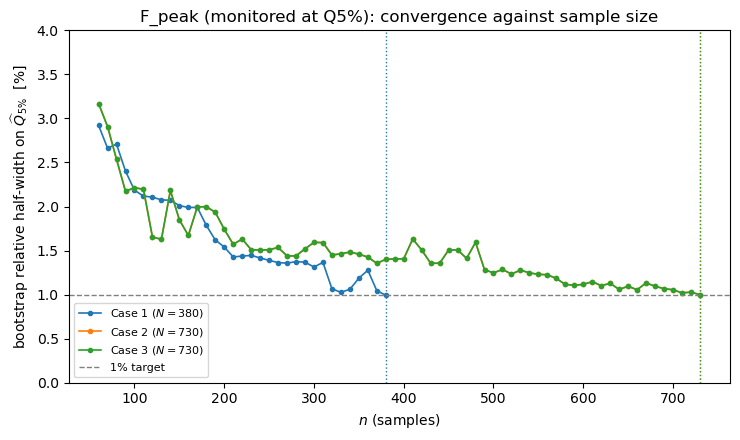

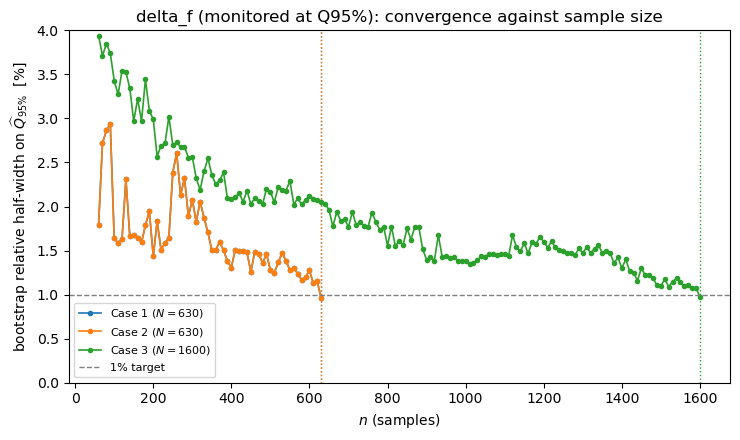

In [8]:
# One figure per output, three curves per figure (one per case), reading each checker's own
# .history -- the list of bootstrap results recorded at every batch during Part 4's run above.
for out_name, p in P_LEVEL.items():
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for c, r in results.items():
        history = r["checkers"][out_name].history
        ns = np.array([h["n"] for h in history])                      # running sample size, per check
        rel_hw = np.array([100 * h["rel_half_width"] for h in history])  # bootstrap half-width, as a %
        stop_n = r["N_out"][out_name]                                 # where THIS output's own criterion passed
        ax.plot(ns, rel_hw, "o-", ms=3, lw=1.2, color=CASE_COLOR[c], label=rf"Case {c} ($N={stop_n}$)")
        ax.axvline(stop_n, color=CASE_COLOR[c], ls=":", lw=1)         # dotted marker at that case's own stop
    ax.axhline(1.0, color="gray", ls="--", lw=1, label="1% target")   # the line every curve must cross
    ax.set_xlabel("$n$ (samples)")
    ax.set_ylabel(rf"bootstrap relative half-width on $\widehat{{Q}}_{{{100*p:.0f}\%}}$  [%]")
    ax.set_title(f"{out_name} (monitored at Q{100*p:.0f}%): convergence against sample size")
    ax.set_ylim(0, 4)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

Both figures wobble noisily at small $n$ and settle toward the 1% line without doing so
monotonically, the same behaviour NB3 and NB4 documented for their own campaigns. In the
$F_{peak}$ figure, Cases 2 and 3 are the same curve, since they share $\mathrm{CoV}_t$ and
$F_{peak}$ cannot see $\mathrm{CoV}_G$; in the $\delta_f$ figure, Cases 1 and 2 coincide for the
mirror reason. The table below reads off where each curve actually crosses the target:

| | $F_{peak}$ (Q5%) | $\delta_f$ (Q95%) | campaign $N$ | binding |
|---|---|---|---|---|
| Case 1 | 380 | 630 | **630** | $\delta_f$ |
| Case 2 | 730 | 630 | **730** | $F_{peak}$ |
| Case 3 | 730 | 1600 | **1600** | $\delta_f$ |

Case 1's $F_{peak}$ sub-campaign converges at $N=380$, NB4's own converged size for its
$\mathrm{CoV}_t=2\%$ campaign. Which output binds the campaign flips along the chain,
tracking exactly which input's scatter was just raised: raising $\mathrm{CoV}_t$
(Case 1&rarr;2) grows only $F_{peak}$'s own cost, so it takes over as the binding output while
$\delta_f$'s criterion, blind to a CoV it cannot see, converges at the identical $N=630$ in both cases; raising $\mathrm{CoV}_G$ (Case 2&rarr;3) does the mirror, growing only
$\delta_f$'s cost while $F_{peak}$'s criterion holds at $N=730$ in both cases. *Which* output a
campaign has to pay for is decided by *which input's scatter was just raised*, as it was predicted in Part 1.

### The converged output distributions

Each case's converged sample already says something, before any index is computed. The cell
below overlays the three cases' distributions for each output on one shared axis, using a
kernel density estimate with **leave-one-out cross-validated bandwidth**
(`kde_loo_bandwidth`, NB2 Part 5's own method: the data chooses its own smoothing rather than a
rule of thumb), with each case's own monitored percentile marked (Q5% for $F_{peak}$, Q95% for $\delta_f$).

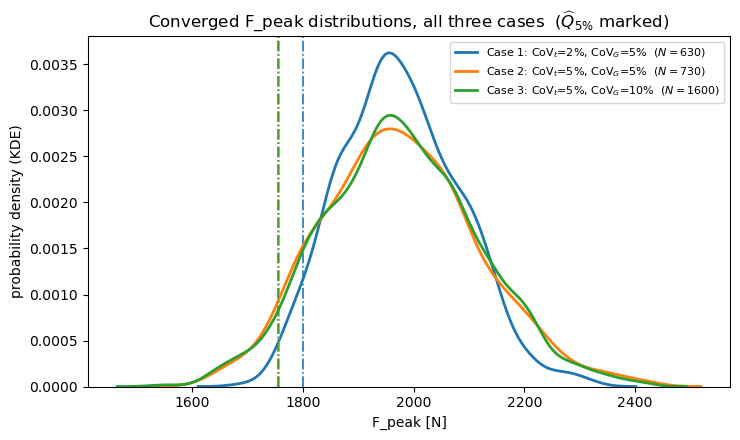

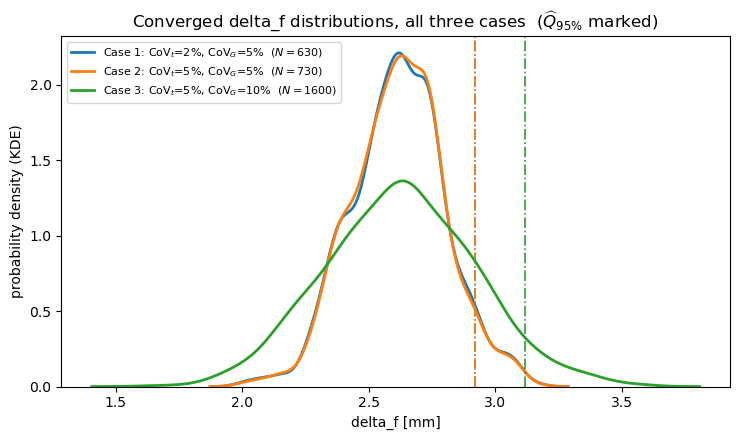

CoV_XT = 5.00% in every case
  case   output     N       mean       std   CoV emp.  CoV exact      Q_hat
---------------------------------------------------------------------------
  -- Case 1: CoV_t=2%, CoV_G=5% --
     1   F_peak   630  1975.8046  108.3039     0.0548     0.0539  1800.8357
     1  delta_f   630     2.6173    0.1861     0.0711     0.0710     2.9202
  -- Case 2: CoV_t=5%, CoV_G=5% --
     2   F_peak   730  1976.1435  140.6159     0.0712     0.0708  1756.1309
     2  delta_f   730     2.6167    0.1841     0.0704     0.0710     2.9202
  -- Case 3: CoV_t=5%, CoV_G=10% --
     3   F_peak  1600  1976.2262  140.3064     0.0710     0.0708  1754.0154
     3  delta_f  1600     2.6255    0.2972     0.1132     0.1121     3.1163


In [9]:
from kde import kde_loo_bandwidth, kde_pdf   # NB2 Part 5's own KDE, unchanged

# One figure per output, one KDE curve per case, all three cases sharing one axis so the
# widening itself -- not just a summary number -- is directly comparable across the chain.
for out_idx, out_name in [(0, "F_peak"), (1, "delta_f")]:
    unit, p = UNIT[out_name], P_LEVEL[out_name]
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for c in CASES:
        r = results[c]
        sample = outputs(r["A"])[out_idx]                  # this case's converged sample of this output
        h = kde_loo_bandwidth(sample)[0]                    # cross-validated bandwidth -- the data picks it
        x_grid = np.linspace(sample.min() - 3 * h, sample.max() + 3 * h, 500)
        ax.plot(x_grid, kde_pdf(x_grid, sample, h), color=CASE_COLOR[c], lw=2,
                label=rf"Case {c}: $\mathrm{{CoV}}_t$={r['cov_t']:.0%}, $\mathrm{{CoV}}_G$={r['cov_g']:.0%}  ($N={len(sample)}$)")
        # dash-dot marker at THIS case's own monitored percentile (Q5% for F_peak, Q95% for delta_f)
        ax.axvline(float(np.percentile(sample, 100 * p)), color=CASE_COLOR[c], ls="-.", lw=1.2)
    ax.set_xlabel(f"{out_name} [{unit}]")
    ax.set_ylabel("probability density (KDE)")
    ax.set_title(rf"Converged {out_name} distributions, all three cases  ($\widehat Q_{{{100*p:.0f}\%}}$ marked)")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

# The numbers behind the two figures: mean, std, empirical CoV against Part 3's exact
# reference (F_peak's from the "F_peak decomposition" subsection, delta_f's from the "delta_f
# decomposition" subsection), and each output's own monitored percentile. CoV_t and CoV_G are
# printed once per case as a header line, since they identify the case; CoV_XT=5% is constant
# and stated once here rather than repeated on every row.
print(f"CoV_XT = {COV_XT:.2%} in every case")
print(f"{'case':>6}{'output':>9}{'N':>6}{'mean':>11}{'std':>10}{'CoV emp.':>11}{'CoV exact':>11}{'Q_hat':>11}")
print("-" * 75)
for c, r in results.items():
    print(f"  -- Case {c}: CoV_t={r['cov_t']:.0%}, CoV_G={r['cov_g']:.0%} --")
    F, D = outputs(r["A"])
    cov_f_ref = np.sqrt(r["cov_t"] ** 2 + COV_XT ** 2 + r["cov_t"] ** 2 * COV_XT ** 2)   # "F_peak decomposition" above
    cov_d_ref = np.sqrt(COV_R ** 2 + r["cov_g"] ** 2 + COV_R ** 2 * r["cov_g"] ** 2)      # "delta_f decomposition" above
    for name, sample, cov_ref in [("F_peak", F, cov_f_ref), ("delta_f", D, cov_d_ref)]:
        emp = sample.std(ddof=1) / sample.mean()
        q = np.percentile(sample, 100 * P_LEVEL[name])
        print(f"{c:>6}{name:>9}{len(sample):6d}{sample.mean():11.4f}{sample.std(ddof=1):10.4f}{emp:11.4f}"
              f"{cov_ref:11.4f}{q:11.4f}")


$F_{peak}$'s three curves share essentially the same centre and widen from Case 1 to
Cases 2/3 (which share $\mathrm{CoV}_t$); $\delta_f$'s curves widen from Case 2 to Case 3, where
$\mathrm{CoV}_G$ doubles. In both panels the marked percentile slides *away* from the mean as
the curve widens &ndash; $F_{peak}$'s Q5% left, $\delta_f$'s Q95% right &ndash; NB2's "the mean
is the wrong number to design against" showing up on opposite tails for a capacity and a
deformation. Every empirical CoV matches its exact reference to within ordinary sampling scatter
at these $N$. What none of this says is *which input* did the widening, which is exactly what
Part 5's indices answer.

## Part 5 &ndash; Estimating the indices from the converged samples

Part 3's exact results exist only because both maps here are simple enough to expand by hand. A
real numerical model offers no such expansion. What is needed is an estimator that computes $S_i$
and $S_i^{\mathrm{tot}}$ from nothing but *evaluations of the model*, for any map at all. This
is the **pick-freeze** design ([Sobol', 2001](https://doi.org/10.1016/S0378-4754(00)00270-6)).

### A note on notation before anything else: $B$ means something new from here on

Part 4 used $B=1000$ for the bootstrap's *number of resamples*. **From this section onward, $B$ instead denotes
a second *sample matrix***; in other words, a whole array of input draws. Read every $B$ from here on as "the second pick-freeze sample," never as a resample count.

### Two samples and a column swap

Draw two independent samples of the input vector, $A$ and $B$, each an $N\times d$ matrix
($N\times3$ here, $d=3$ inputs): **one row per Monte Carlo draw** &ndash; where row $j$ of $A$ is the
$j$-th realisation of the input vector $(t,X_T,G_{fT})$ &ndash; and
**one column per input** &ndash; where column 1 is every draw's $t$, column 2 every draw's $X_T$, column 3
every draw's $G_{fT}$.

$A$ is nothing new: it is exactly the converged sample each case's campaign in Part 4
already produced. $B$ is a second, equally sized sample from the *same* three marginals, drawn
from an independent set of seeds. For each input $i$, define $A_B^{(i)}$ as $A$ with **only
column $i$ replaced by $B$'s column $i$**: every other column still comes from $A$. The cell
below draws a tiny illustrative pair (four rows, Case 1's CoVs) and prints $A$, $B$ and
$A_B^{(t)}$ side by side, so the column swap is concrete before it is used at full scale.

In [10]:
SEED_B = dict(t=14, x=12, g=16)   # a second, independent seed per input -- the "B" sample matrix's own stream


def pick_freeze(A, B):
    """A, B: (N, 3) arrays [t, X_T, G_fT]. Returns a list of three (N, 3) arrays A_B^(i),
    i = 0 (t), 1 (X_T), 2 (G_fT) -- A with ONLY column i replaced by B's column i."""
    ABs = []
    for i in range(3):
        AB = A.copy()
        AB[:, i] = B[:, i]
        ABs.append(AB)
    return ABs


# A tiny illustration: 4 rows at Case 1's CoVs, to see the column swap directly.
cov_t_demo, cov_g_demo = CASES[1]
A_demo = draw_pool(cov_t_demo, cov_g_demo, 4, seeds=SEED_A)
B_demo = draw_pool(cov_t_demo, cov_g_demo, 4, seeds=SEED_B)
AB_t_demo = pick_freeze(A_demo, B_demo)[0]   # column 0 (t) swapped in from B

labels = ["t", "X_T", "G_fT"]
print("A (every column from the A stream):")
print(A_demo)
print("\nB (every column from the B stream):")
print(B_demo)
print("\nA_B^(t) (A, with ONLY the t column replaced by B's t column):")
print(AB_t_demo)


A (every column from the A stream):
[[1.97392835e-01 9.99358142e+02 1.35792597e+03]
 [1.99301131e-01 9.64123952e+02 1.40458369e+03]
 [2.06654896e-01 9.69553355e+02 1.12531268e+03]
 [2.02636591e-01 8.69147365e+02 1.28110125e+03]]

B (every column from the B stream):
[[2.02782079e-01 9.89662074e+02 1.25164032e+03]
 [1.96082103e-01 1.04178409e+03 1.33068553e+03]
 [1.93706039e-01 1.02670863e+03 1.35703834e+03]
 [1.88300118e-01 1.02583585e+03 1.35649445e+03]]

A_B^(t) (A, with ONLY the t column replaced by B's t column):
[[2.02782079e-01 9.99358142e+02 1.35792597e+03]
 [1.96082103e-01 9.64123952e+02 1.40458369e+03]
 [1.93706039e-01 9.69553355e+02 1.12531268e+03]
 [1.88300118e-01 8.69147365e+02 1.28110125e+03]]


$A_B^{(t)}$'s $X_T$ and $G_{fT}$ columns are $A$'s own, unchanged; only its $t$ column
comes from $B$. This is also the origin of the exact-zero prediction from Part 1, made fully
explicit: if input $i$ is not an argument of $f$ at all, swapping its column changes nothing
$f$ can see, so $f(A_B^{(i)})$ and $f(A)$ are identical, row by row, for any $N$ and any draw.
Every estimator built from the *difference* $f(A)-f(A_B^{(i)})$ inherits that exact zero
automatically.

**How this attaches to a campaign.** Part 4 grew and converged each case's $A$ sample against
the percentile criterion; that same $N$ rows is reused here as $A$, and a fresh $B$ of the same
size $N$ is drawn from the independent seeds above. Evaluating both outputs on $A$, on $B$, and on each of the $d=3$
recombinations $A_B^{(i)}$ costs $N$ evaluations five times over: $N(d+2)=5N$ at $d=3$, and
because $F_{peak}$ and $\delta_f$ are evaluated on the very same rows throughout, that same $5N$
serves *both* outputs at once.

### The estimator

Building the estimator takes a few small, separately justified steps: why an output can be
shifted by a constant for free, why doing so is actually useful here, and then the two
estimator formulas themselves, each derived from the pick-freeze construction above rather than
just stated.

**1. Shifting by a constant changes no Sobol' index.** For any constant $c$,
$\mathrm{Var}(f+c)=\mathrm{Var}(f)$: in other words, adding a constant slides every value by the same
amount and does not change how spread out they are. The same is true of every partial variance
$D_S$ from Part 2, since each $f_S$ (for $S\ne\emptyset$) is unaffected by a shift applied to
$f_0$ alone. So replacing $f$ by $f-c$, for *any* constant $c$, leaves every $D_S$ and hence
every Sobol' index $S_{i_1\cdots i_s}=D_{i_1\cdots i_s}/D$ exactly unchanged: numerator and
denominator are unaffected.

**2. Variance is a difference of two big, close numbers.** The computable form
$\mathrm{Var}=\mathrm E[f^2]-\mathrm E[f]^2$ (Part 2) subtracts two numbers that can be nearly
equal when the mean is large relative to the spread. Concretely, for $F_{peak}$ pooled over Case 2's own $A,B$ at the demo sample size below:
$\mathrm E[F_{peak}^2]\approx3.941\times10^6$ against $\mathrm
E[F_{peak}]^2\approx3.921\times10^6$, a difference of only about $1.96\times10^4$. The two
numbers agree to three significant figures before the subtraction even starts, so the *answer*
is built entirely from digits that were about to be lost to rounding. Subtracting the sample
mean *first*, before squaring anything, puts every value on the same scale as the spread itself
and avoids this ([Sobol', 2001](https://doi.org/10.1016/S0378-4754(00)00270-6)).

**3. What is actually done.** Pool every output value from $A$ and $B$ together ($2N$ values in
total) and compute their combined average, called $c_0$, the **pooled sample mean**.
Every output is then re-expressed as its distance from that one number: $\tilde f\equiv f-c_0$.
By Step 1 this changes no index; by Step 2 it is why the arithmetic below stays accurate.

**4. Calculate the total variance** from the pooled, shifted sample: $\widehat D = \frac1{2N}\sum_{A\cup B}\tilde
f^2 - \big(\frac1{2N}\sum_{A\cup B}\tilde f\big)^2$.

**5. First-order index, derived.** The intuition first: freeze input $i$ at whatever value it
took in $B$'s row $j$, but let every *other* input take $A$'s independent draw for that same
row. That is exactly $A_B^{(i)}$'s row $j$. Whatever $B$'s output and $A_B^{(i)}$'s
output still have in common, having only column $i$ pinned between them, is what input $i$
alone explains. Made precise: $B$ and $A_B^{(i)}$ share *exactly* column $i$ and nothing else, so feeding both into Part 2's decomposition and averaging their product, every
term-pair average vanishes by Step 1's orthogonality (Part 2) except the one term both sides
actually share, $f_i$, leaving
$$\mathrm E\big[\tilde f(B)\,\tilde f(A_B^{(i)})\big] = \mathrm E[f_i^2] = D_i.$$
One refinement remains: $A$ and $B$ share no rows at all, so $\mathrm E[\tilde f(A)\tilde
f(B)]=0$ exactly, and subtracting that (zero, in expectation) quantity from the product above
changes nothing on average but cancels sampling noise the two terms share. This is the
lower-variance form [Sobol' (2001)](https://doi.org/10.1016/S0378-4754(00)00270-6) recommends.
That gives the estimator actually used:
$$\widehat D_i=\frac1N\sum_j
  \tilde f(B)_j\big[\tilde f(A_B^{(i)})_j-\tilde f(A)_j\big], \qquad \widehat S_i=\widehat
  D_i/\widehat D.$$

**6. Total index, derived.** $A$ and $A_B^{(i)}$ differ in *only* column $i$; every other
column is identical row by row. Split the decomposition in two accordingly, and write
$$g \equiv \sum_{S\ni i} f_S$$
for the part of $f$ that involves input $i$ &ndash; every term of which carries $x_i$ among its
own arguments. Every *other* term of $f$ depends only on inputs the two samples share, so it
takes the same value on both sides and cancels exactly in the difference
$f(A)_j-f(A_B^{(i)})_j$. What is left is $g$ alone, evaluated twice: at **the same values of
every input other than $i$** (both taken from $A$), but at **two independent draws of $x_i$**
&ndash; $A$'s on one side, $B$'s on the other. Calling those two evaluations $g_A$ and $g_B$,
$$\mathrm E\big[(g_A-g_B)^2\big]=\mathrm E[g_A^2]+\mathrm E[g_B^2]-2\,\mathrm E[g_Ag_B]
= D_i^{\mathrm{tot}}+D_i^{\mathrm{tot}}-0 = 2\,D_i^{\mathrm{tot}}.$$
The first two terms are each $D_i^{\mathrm{tot}}$: either way $g$ is evaluated at a perfectly
ordinary full random draw, and since $\mathrm E[g]=0$ its second moment *is* its variance, which
collects every partial variance input $i$ appears in &ndash; the definition of the total-effect
variance. The cross term vanishes for the reason Part 2 already supplied: hold the shared inputs
fixed, and $g_A$ and $g_B$ differ only through two independent draws of $x_i$, so the average of
their product over those draws is $\big(\mathrm E_{x_i}[g\mid x_{\setminus i}]\big)^2$ &ndash;
and that inner average is $\sum_{S\ni i}\mathrm E_{x_i}[f_S]=0$, because $i$ is one of the *own
arguments* of every term in $g$, which is exactly what the zero-mean condition annihilates (and
it is zero whatever the held-fixed inputs are, which is what lets the outer average inherit it).
That factor of 2 is where the leading $\tfrac1{2N}$ below comes from:
$$\widehat{D_i^{\mathrm{tot}}}=\frac1{2N}\sum_j\big[f(A)_j-f(A_B^{(i)})_j\big]^2,
\qquad \widehat S_i^{\mathrm{tot}}=\widehat{D_i^{\mathrm{tot}}}/\widehat D.$$

Sobol' (2001) shows these two particular forms, the paired product for the
first-order index and the squared difference for the total, are each the lower-variance
estimator among the alternatives available.

The cell below turns Steps 3&ndash;6 into six lines of arithmetic, then runs them at Case 2's
CoVs and compares straight against Part 3's exact answer. The sample size there is deliberately
large: the question this check asks is whether the *estimator* converges to the right number,
and both maps here are closed-form arithmetic rather than Abaqus solves, so $5N$ evaluations at
$N=100{,}000$ cost milliseconds.


In [11]:
def sobol_indices_pf(f_A, f_B, f_ABs):
    """The pick-freeze Sobol' estimator derived above (Sobol', 2001, eqs. 5/6/8/9).
    f_A, f_B: (2, N) arrays, row 0 = F_peak, row 1 = delta_f, evaluated on A and B.
    f_ABs: list of three (2, N) arrays, the same two outputs evaluated on each A_B^(i).
    Returns (S, ST), each (2, 3): rows = [F_peak, delta_f], columns = [t, X_T, G_fT]."""
    # Step 3: c0 is the pooled mean over every row of A and B combined -- one number per output
    # (kept 2D via keepdims so it broadcasts against f_A/f_B/f_AB below without reshaping).
    c0 = np.concatenate([f_A, f_B], axis=1).mean(axis=1, keepdims=True)
    a, b = f_A - c0, f_B - c0                               # Step 3: the shifted outputs, f_tilde(A) and f_tilde(B)
    D = np.concatenate([a, b], axis=1).var(axis=1)           # Step 4: total variance, pooled A u B

    S = np.empty((f_A.shape[0], 3))
    ST = np.empty((f_A.shape[0], 3))
    for i, f_AB in enumerate(f_ABs):
        ab = f_AB - c0                                        # this input's A_B^(i), shifted the same way
        S[:, i] = (b * (ab - a)).mean(axis=1) / D             # Step 5: paired first-order estimator
        ST[:, i] = 0.5 * ((a - ab) ** 2).mean(axis=1) / D      # Step 6: squared-difference total estimator
    return S, ST


def build_AB(cov_t, cov_g, N):
    """Draw a fresh A and B at the given CoVs and sample size, and the three pick-freeze
    recombinations, in one call."""
    A = draw_pool(cov_t, cov_g, N, seeds=SEED_A)
    B = draw_pool(cov_t, cov_g, N, seeds=SEED_B)
    f_A, f_B = outputs(A), outputs(B)
    f_ABs = [outputs(AB) for AB in pick_freeze(A, B)]
    return f_A, f_B, f_ABs


# Sanity check: run the estimator at Case 2's CoVs (the exact-tie case, Part 3's sharpest
# prediction) and compare directly against the exact reference. N is deliberately large here:
# these two maps are closed-form arithmetic, not Abaqus solves, so the 5N = 500,000 evaluations
# this costs take milliseconds, and the question being asked is whether the ESTIMATOR converges
# to the exact answer -- not what a percentile-sized campaign can afford, which is what Part 5's
# own results further below are about.
N_DEMO = 100_000
f_A, f_B, f_ABs = build_AB(*CASES[2], N=N_DEMO)
S_demo, ST_demo = sobol_indices_pf(f_A, f_B, f_ABs)
S_exact, ST_exact = exact_indices_fpeak(CASES[2][0])

print(f"Case 2, N={N_DEMO}, F_peak row  [t, X_T, G_fT]:")
print(f"  pick-freeze  S ={np.array2string(S_demo[0], precision=4)}  ST={np.array2string(ST_demo[0], precision=4)}")
print(f"  exact        S ={np.array2string(S_exact, precision=4)}  ST={np.array2string(ST_exact, precision=4)}")
# The single number the markdown below quotes: the largest miss anywhere in this row.
worst = np.max(np.abs(np.concatenate([S_demo[0] - S_exact, ST_demo[0] - ST_exact])))
print(f"  worst absolute error, over all six entries above: {worst:.4f}  ({100 * worst:.2f} percentage points)")


Case 2, N=100000, F_peak row  [t, X_T, G_fT]:
  pick-freeze  S =[0.5027 0.4995 0.    ]  ST=[0.5021 0.5001 0.    ]
  exact        S =[0.4994 0.4994 0.    ]  ST=[0.5006 0.5006 0.    ]
  worst absolute error, over all six entries above: 0.0033  (0.33 percentage points)


The code reproduces the reference closely at this sample size. The largest miss anywhere in the $F_{peak}$ row is $\widehat S_t = 0.5027$ against
an exact $0.4994$: an absolute error of $0.0033$, or **0.33 percentage points**, with every
other entry inside $0.15$ points and $G_{fT}$'s column exactly zero.

### Cross-check against SciPy

We cross-check our implementation against `scipy.stats.sobol_indices`, which implements the identical pair of estimators (its
`method="saltelli_2010"` refers to the same product/squared-difference pairing derived above)
and accepts precomputed model evaluations directly, via an `{"f_A", "f_B", "f_AB"}` dictionary, exactly the arrays `sobol_indices_pf` already builds. The reason why SciPy is used here only as an independent check and not in place of the hand-written estimator is given by the fact that `scipy.stats.sobol_indices` requires $N$ to be a power of 2, whereas the campaigns above converge on NB3's 10-sample batch grid and will not in general land on a power of 2. Running both implementations on the
same draw, at a sample size chosen to suit SciPy, is a direct test that the estimator above is not silently wrong.

In [12]:
from scipy.stats import sobol_indices as scipy_sobol_indices

N_CHECK_SCIPY = 2 ** 11   # power of 2, required by scipy.stats.sobol_indices
cov_t_chk, cov_g_chk = CASES[2]

A_chk = draw_pool(cov_t_chk, cov_g_chk, N_CHECK_SCIPY, seeds=SEED_A)
B_chk = draw_pool(cov_t_chk, cov_g_chk, N_CHECK_SCIPY, seeds=SEED_B)
f_A_chk, f_B_chk = outputs(A_chk), outputs(B_chk)
f_AB_chk = np.array([outputs(AB) for AB in pick_freeze(A_chk, B_chk)])   # shape (3, 2, N) -- scipy's own f_AB convention

S_own, ST_own = sobol_indices_pf(f_A_chk, f_B_chk, list(f_AB_chk))
res = scipy_sobol_indices(func={"f_A": f_A_chk, "f_B": f_B_chk, "f_AB": f_AB_chk}, n=N_CHECK_SCIPY)

print(f"N = {N_CHECK_SCIPY}, Case 2")
print(f"  max |S difference|  = {np.abs(S_own - res.first_order).max():.2e}")
print(f"  max |ST difference| = {np.abs(ST_own - res.total_order).max():.2e}")

N = 2048, Case 2
  max |S difference|  = 0.00e+00
  max |ST difference| = 0.00e+00


The two implementations' maximum difference, over every index and every input, is
*exactly* `0.00e+00`, in other words, bit-for-bit identical floating-point
output. The hand-written estimator computes exactly what SciPy computes, verified
independently rather than assumed.

### The indices, at each case's converged sample

Each case's $A$ sample is already in hand, from Part 4's campaign. The cell below draws a
matching $B$ at the same $N$, forms the pick-freeze indices for both outputs, and compares them
against Part 3's exact references. These campaigns were sized to converge a *percentile*, not
an index, so noticeably more sampling scatter can be expected here than in the $N=100{,}000$ check
above. That check already established that the estimator itself converges to the exact answer,
so whatever gap appears below is the price of each campaign's own $N$; comparing against the exact reference is what makes that price visible.

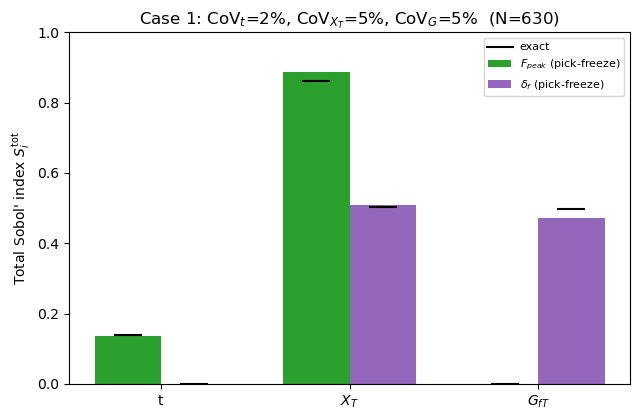

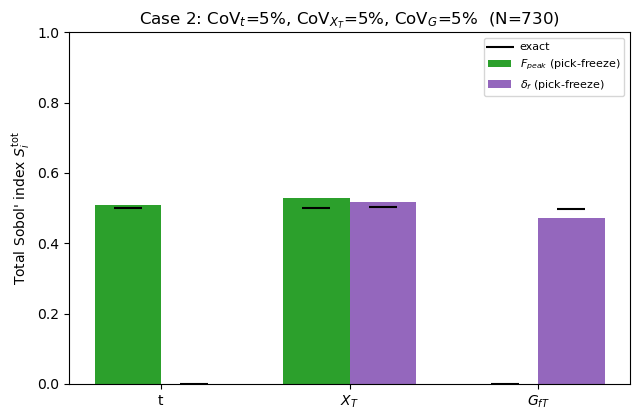

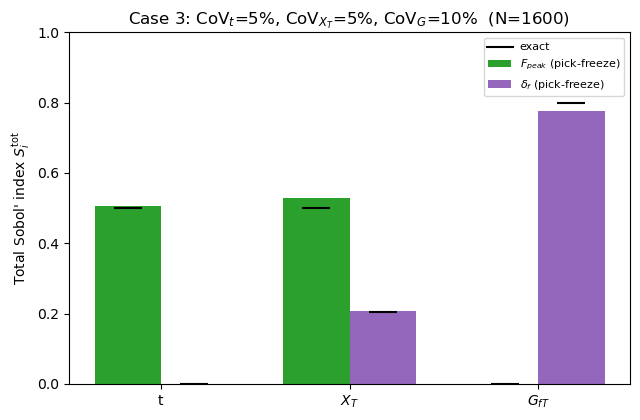

  case   output  input          S  S exact         ST ST exact
--------------------------------------------------------------
  -- Case 1: CoV_t=2%, CoV_XT=5%, CoV_G=5% --
     1   F_peak      t     0.1024   0.1379     0.1367   0.1382
     1   F_peak    X_T     0.8360   0.8618     0.8877   0.8621
     1   F_peak   G_fT     0.0000   0.0000     0.0000   0.0000
     1  delta_f      t     0.0000   0.0000     0.0000   0.0000
     1  delta_f    X_T     0.5099   0.5032     0.5094   0.5044
     1  delta_f   G_fT     0.5140   0.4956     0.4726   0.4968
  -- Case 2: CoV_t=5%, CoV_XT=5%, CoV_G=5% --
     2   F_peak      t     0.4494   0.4994     0.5092   0.5006
     2   F_peak    X_T     0.4784   0.4994     0.5289   0.5006
     2   F_peak   G_fT     0.0000   0.0000     0.0000   0.0000
     2  delta_f      t     0.0000   0.0000     0.0000   0.0000
     2  delta_f    X_T     0.5370   0.5032     0.5184   0.5044
     2  delta_f   G_fT     0.5119   0.4956     0.4722   0.4968
  -- Case 3: CoV_t=5%, CoV

In [13]:
INPUT_LABELS = ["t", "$X_T$", "$G_{fT}$"]
OUTPUT_LABELS = ["F_peak", "delta_f"]

# For each case: reuse Part 4's own converged A, draw a matching B at the same N, form the
# pick-freeze estimate for both outputs, and stack the exact references alongside it for the
# comparison below (F_peak's from the "F_peak decomposition" subsection of Part 3, delta_f's
# from the "delta_f decomposition" subsection).
indices = {}
for c, r in results.items():
    A, N = r["A"], r["N"]
    B = draw_pool(r["cov_t"], r["cov_g"], N, seeds=SEED_B)
    f_A, f_B = outputs(A), outputs(B)
    f_ABs = [outputs(AB) for AB in pick_freeze(A, B)]
    S, ST = sobol_indices_pf(f_A, f_B, f_ABs)
    S_f_exact, ST_f_exact = exact_indices_fpeak(r["cov_t"])
    S_d_exact, ST_d_exact = exact_indices_deltaf(r["cov_g"])
    indices[c] = dict(S=S, ST=ST, S_exact=np.vstack([S_f_exact, S_d_exact]),
                       ST_exact=np.vstack([ST_f_exact, ST_d_exact]))

# The bar charts: one figure per case, three inputs on x, total-index bars grouped by output.
for c, r in results.items():
    idx = indices[c]
    fig, ax = plt.subplots(figsize=(6.5, 4.3))
    x = np.arange(3)
    width = 0.35
    ax.bar(x - width / 2, idx["ST"][0], width, color="C2", label="$F_{peak}$ (pick-freeze)")
    ax.bar(x + width / 2, idx["ST"][1], width, color="C4", label="$\\delta_f$ (pick-freeze)")
    ax.scatter(x - width / 2, idx["ST_exact"][0], marker="_", s=400, color="k", zorder=3, label="exact")
    ax.scatter(x + width / 2, idx["ST_exact"][1], marker="_", s=400, color="k", zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(INPUT_LABELS)
    ax.set_ylabel("Total Sobol' index $S_i^{\\mathrm{tot}}$")
    ax.set_ylim(0, 1.0)
    ax.set_title(rf"Case {c}: $\mathrm{{CoV}}_t$={r['cov_t']:.0%}, $\mathrm{{CoV}}_{{X_T}}$={COV_XT:.0%}, "
                 rf"$\mathrm{{CoV}}_G$={r['cov_g']:.0%}  (N={r['N']})")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

# The full table: pick-freeze estimate vs. exact reference, first-order and total, both outputs.
# Each case's own three CoVs are printed as a header line above its six rows (two outputs times
# three inputs), so the table never has to be cross-referenced back to Part 1's case table.
print(f"{'case':>6}{'output':>9}{'input':>7}   {'S':>8}{'S exact':>9}   {'ST':>8}{'ST exact':>9}")
print("-" * 62)
for c in CASES:
    r = results[c]
    print(f"  -- Case {c}: CoV_t={r['cov_t']:.0%}, CoV_XT={COV_XT:.0%}, CoV_G={r['cov_g']:.0%} --")
    idx = indices[c]
    for oi, oname in enumerate(OUTPUT_LABELS):
        for ii, iname in enumerate(["t", "X_T", "G_fT"]):
            print(f"{c:>6}{oname:>9}{iname:>7}   {idx['S'][oi, ii]:8.4f}{idx['S_exact'][oi, ii]:9.4f}   "
                  f"{idx['ST'][oi, ii]:8.4f}{idx['ST_exact'][oi, ii]:9.4f}")

# Persist the converged indices.
sobol_summary = {}
for c, r in results.items():
    idx = indices[c]
    sobol_summary[str(c)] = dict(
        cov_t=r["cov_t"], cov_g=r["cov_g"], N=r["N"],
        S={OUTPUT_LABELS[oi]: {lab: float(idx["S"][oi, ii]) for ii, lab in enumerate(["t", "X_T", "G_fT"])}
           for oi in range(2)},
        ST={OUTPUT_LABELS[oi]: {lab: float(idx["ST"][oi, ii]) for ii, lab in enumerate(["t", "X_T", "G_fT"])}
            for oi in range(2)},
        S_exact={OUTPUT_LABELS[oi]: {lab: float(idx["S_exact"][oi, ii]) for ii, lab in enumerate(["t", "X_T", "G_fT"])}
                 for oi in range(2)},
        ST_exact={OUTPUT_LABELS[oi]: {lab: float(idx["ST_exact"][oi, ii]) for ii, lab in enumerate(["t", "X_T", "G_fT"])}
                  for oi in range(2)},
    )
with open(RUNS_DIR / "sobol_summary.json", "w") as fh:
    json.dump(sobol_summary, fh, indent=2)
print(f"\nwrote sobol_summary.json to {RUNS_DIR.as_posix()}/")


Every bar for $G_{fT}$ under $F_{peak}$, and every bar for $t$ under $\delta_f$, sits at
zero, as Part 1 predicted. Most pick-freeze bars track their exact markers closely, ordinary
Monte Carlo scatter at each campaign's own $N$; the largest single gap in the table is Case 1's
$S_{X_T}^{\mathrm{tot}}$ for $F_{peak}$, about 2.6 percentage points above its exact value
(0.888 vs. 0.862), still small next to the 14/86 split it sits on.

## Discussion

**Which input dominates, and how the dominance moves.** At Case 1, $F_{peak}$ is dominated by
$X_T$ (total index $\approx0.86$ against $t$'s $\approx0.14$); Case 2 collapses that gap to an
exact tie, exactly as Part 3's $F_{peak}$ derivation predicted, while $\delta_f$'s indices hold still across the same step, since $t$ never enters its formula. The
mirror happens from Case 2 to Case 3: $\delta_f$'s split moves from near 50/50 toward $G_{fT}$'s favour as $\mathrm{CoV}_G$ doubles, while $F_{peak}$'s indices hold still. Both halves of the chain prediction from Part 4 came through, and for the reason stated there: each formula can only respond to the CoVs of the inputs that actually appear in it.

**What the exact zeros license.** $S_{G_{fT}}^{\mathrm{tot}}\approx0$ for $F_{peak}$ in every
case means $G_{fT}$ could be fixed at its nominal value in any future study of $F_{peak}$ with
no meaningful consequence. The mirror statement holds for $t$ and $\delta_f$: a concrete, checkable basis for
deciding which random inputs a later, more expensive study can afford to drop.


## Conclusion

NB4 could only observe, by inspection of $F_{peak}=w\,t\,X_T$, that $G_{fT}$ has no effect on
it whatsoever. What no formula alone can settle is how much *each argument that does appear* actually matters, since that depends on each
input's own scatter as well as the map's shape. This notebook built the tool that answers that
question without needing a formula at all: the Sobol' index.

**What this notebook established:**

- **What a Sobol' index means, derived rather than quoted.** The Sobol' decomposition splits an
  output's variance, without approximation, into a piece owned by each input alone and a piece
  owned by each interacting group. $S_i$ answers "how much would revealing $X_i$ alone
  explain"; $S_i^{\mathrm{tot}}$ answers "how much would remain unexplained if $X_i$ were the
  only input left uncertain," and it is the total index that licenses fixing an input as
  deterministic.
- **Both outputs, exact.** $F_{peak}=w\,t\,X_T$ and $\delta_f=2G_{fT}\cdot(1/X_T)$ are both
  products of independent factors, so both have exact Sobol' indices, with no
  distributional assumption beyond independence and finite variance. $\delta_f$'s only
  non-elementary ingredient, $\mathrm{CoV}(1/X_T)$, comes from a one-dimensional numerical quadrature, not from any approximation to the indices themselves.
- **The pick-freeze estimator, derived and checked.** Two samples $A,B$ and one column-swap
  $A_B^{(i)}$ per input give both $S_i$ and $S_i^{\mathrm{tot}}$ at a shared cost of
  $N(d+2)=5N$ model evaluations for $d=3$ inputs, serving both outputs from the same draws.
  `scipy.stats.sobol_indices` reproduced the hand-derived formulas to floating-point precision.
- **Three campaigns, one stopping rule, two outputs at once.** NB3's bootstrap criterion,
  applied to $F_{peak}$ (Q5%) and $\delta_f$ (Q95%) simultaneously, converged the three cases at
  $N=630,\,730,\,1600$, with *which* output bound the campaign tracking exactly which input's
  scatter had just been raised; Case 1 reproduced NB4's own $N=380$ exactly.
- **The chain, confirmed with real numbers.** Raising $\mathrm{CoV}_t$ alone moved $F_{peak}$
  from a 14/86 split to a tie, leaving $\delta_f$ untouched; raising $\mathrm{CoV}_{G_{fT}}$
  alone then moved $\delta_f$ toward $G_{fT}$'s favour, leaving $F_{peak}$ untouched. Each step is
  traceable to Part 1's fact that an input absent from a formula cannot move that
  formula's indices.

**Where this goes next.** Case 3's campaign needed $N=1600$, so a pick-freeze index estimate for
it costs $5N=8000$ model evaluations. At the cost of  the single-shell-element fiber-tension test, $20.7$ s per solve on average,
`nlgeom=OFF`, that is $8000\times20.7\,\mathrm s\approx46$ hours. NB6 moves to a
genuinely heavier deterministic model, an open-hole plate in tension, at a per-solve cost well
above the single element's. We will see that running such a model $N(d+2)$ times over, for every case a real
sensitivity study needs, is not a viable way to get a Sobol' index in that setting. The gap
between what direct variance-based UQ costs and what is actually affordable is why in NB7 we will introduce a **surrogate model**: something fast enough to evaluate $N(d+2)$ times, or far more, standing in for the Abaqus solve wherever this notebook's estimator needs a model evaluation.